# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)
*Classification, clustering, ranking, or scoring — which one, and why?*

This is a **classification** task. The objective is to predict whether a given page is 'declining' or not. This is indicated by the `is_declining_label` column, which is a binary variable (0 or 1) derived from the `trend_direction` feature. Specifically, we are predicting one of two discrete classes: 'declining' (1) or 'not declining' (0).

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# The label: a page is 'declining' when its recent trend is down. Simple, honest starter label.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))

30000 pages |  declining rate: 0.542


In [2]:
#Running the pipeline again
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py


▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


**54.21% pages are declining**

In [4]:
# Show the distribution of the 'is_declining_label'
print("Distribution of 'is_declining_label':")
display(df['is_declining_label'].value_counts())

print("\nPercentage of 'is_declining_label':")
display(df['is_declining_label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Distribution of 'is_declining_label':


,count
is_declining_label,
1,16262
0,13738



Percentage of 'is_declining_label':


,proportion
is_declining_label,
1,54.21%
0,45.79%


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

The model predicts the `is_declining_label`, which is a binary indicator (0 or 1) signifying whether a page is in decline. This label is derived from the `trend_direction` feature, where 'down' is mapped to 1 (declining) and other directions are mapped to 0 (not declining). This is a **defined rule** based on the observed `trend_direction` of the page. It serves as a proxy for actual page decline, which might be harder to directly measure and predict in real-time.

In [5]:
# Display the first few rows showing the 'trend_direction' and 'is_declining_label'
print("First 5 rows showing 'trend_direction' and 'is_declining_label':")
display(df[['trend_direction', 'is_declining_label']].head())

# Display some descriptive statistics for the label
print("\nDescriptive statistics for 'is_declining_label':")
display(df['is_declining_label'].describe())

First 5 rows showing 'trend_direction' and 'is_declining_label':


,trend_direction,is_declining_label
0,down,1
1,down,1
2,down,1
3,stable,0
4,down,1



Descriptive statistics for 'is_declining_label':


,is_declining_label
count,30000.000000
mean,0.542067
std,0.498236
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


## 3. Success metric

*One metric you can defend. What number means 'good'?*

The most appropriate success metric for this task is **Precision@50**. This metric directly measures the quality of the model's top recommendations. In a content refresh scenario, if we can only act on a limited number of pages (e.g., the top 50 most likely to be declining), it's crucial that these selected pages are indeed declining. A high precision at K means that our efforts are focused on genuinely problematic content, minimizing wasted resources on non-declining pages.

**What number means 'good'?**
A higher Precision@50 is better. A 'good' number would be significantly above a random baseline. For instance, if a random selection yields a Precision@50 of 0.2, then a model achieving 0.74 (as seen with the Random Forest model) is considered very good, indicating that 74% of its top 50 predictions are correct.

In [6]:
import json

# Load the model results if not already loaded (defensive programming)
if 'res' not in locals():
    res = json.load(open("outputs/model_results.json"))

base_precision_at_50 = res["baseline"]["baseline_precision_at_50"]
rf_precision_at_50 = res["models"]["random_forest"]["precision_at_50"]

print(f"Baseline Precision@50: {base_precision_at_50:.3f}")
print(f"Random Forest Precision@50: {rf_precision_at_50:.3f}")

# Calculate how much better the learned model is
if base_precision_at_50 > 0:
    improvement_factor = rf_precision_at_50 / base_precision_at_50
    print(f"\nThe learned model is approximately {improvement_factor:.1f}x better than the baseline on Precision@50.")
else:
    print("\nCannot calculate improvement factor as baseline Precision@50 is zero.")

Baseline Precision@50: 0.240
Random Forest Precision@50: 0.740

The learned model is approximately 3.1x better than the baseline on Precision@50.


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

Each row in the dataframe `df` represents a single, unique **content item (or 'page')**. This content item is identified by its `content_id`. Each row contains various features describing that content item, such as its performance metrics, metadata, and the derived `is_declining_label`.

In [9]:
# Display a slice of the DataFrame to show the unit of analysis.
# We'll select a few relevant columns to illustrate what one row represents.
display(df[['content_id', 'client_id', 'search_volume', 'competition', 'pageviews_90d', 'is_declining_label']].head())

,content_id,client_id,search_volume,competition,pageviews_90d,is_declining_label
0,content_304f48230142,client_f369cb89fc,10.0,0.67,22,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,10,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,14,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,87,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,177,1


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

A fixed rule, based on simple `if-else` statements, struggles to capture the intricate and often non-linear relationships between multiple features.

Machine learning models, such as Random Forest, can learn these nuanced interactions across many features simultaneously. They can identify patterns where, for instance, a medium `search_volume` coupled with a certain `age_tier` implies a high likelihood of decline, whereas a similar `search_volume` with a different `age_tier` does not. This multivariate, non-linear pattern recognition is beyond the capability of a few hand-coded `if` statements.



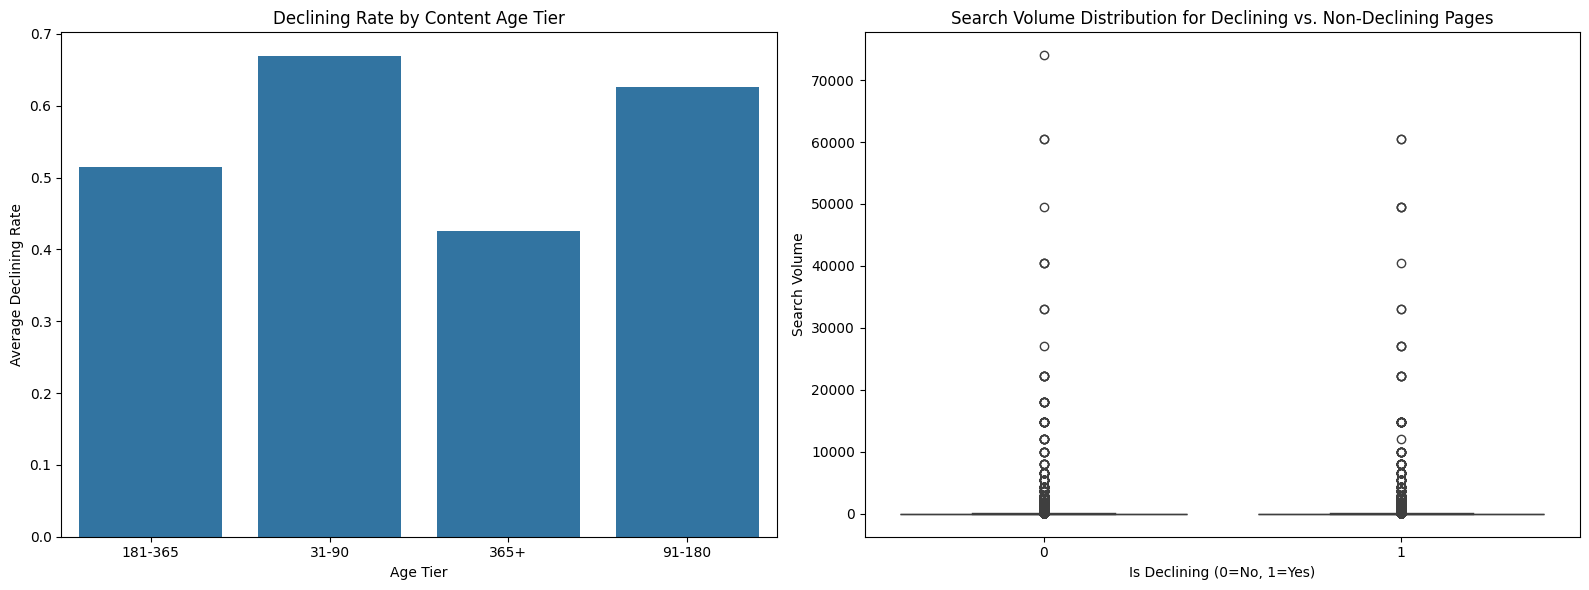


Average search volume for non-declining pages (0): 191.86
Average search volume for declining pages (1): 133.38


In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze declining rate by age_tier to show non-linear patterns
# This helps show that decline is not uniformly distributed across age groups,
# making a simple rule based on age alone insufficient.
decline_rate_by_age = df.groupby('age_tier')['is_declining_label'].mean().reset_index()

# Create a figure with two subplots for easier comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Declining Rate by Content Age Tier
sns.barplot(x='age_tier', y='is_declining_label', data=decline_rate_by_age, ax=axes[0])
axes[0].set_title('Declining Rate by Content Age Tier')
axes[0].set_ylabel('Average Declining Rate')
axes[0].set_xlabel('Age Tier')

# Plot 2: Search Volume Distribution for Declining vs. Non-Declining Pages
# This illustrates that 'search_volume' alone doesn't linearly separate declining pages, and its interaction with other features might be complex.
sns.boxplot(x='is_declining_label', y='search_volume', data=df, ax=axes[1])
axes[1].set_title('Search Volume Distribution for Declining vs. Non-Declining Pages')
axes[1].set_ylabel('Search Volume')
axes[1].set_xlabel('Is Declining (0=No, 1=Yes)')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the plots

# Print average search volumes for a quantitative comparison
print("\nAverage search volume for non-declining pages (0):", df[df['is_declining_label'] == 0]['search_volume'].mean().round(2))
print("Average search volume for declining pages (1):", df[df['is_declining_label'] == 1]['search_volume'].mean().round(2))

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.